# Data Exploration with Droughts

Necessary Imports

In [43]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [44]:
county = "Fresno"
df = pd.read_csv(f'../../data/{county.lower()}_agg_drought.csv')

In [45]:
df

,YEAR_MONTH,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,POUNDS_PRODUCT_APPLIED,Avg_Monthly_DSCI
0,2008-10,6.156349,163.91,0.18,0.0,3.667742,87.825806,70.0,53.0,0,23.056051,782.3835,515.4225
1,2008-11,3.407979,17.30,1.49,0.0,3.106667,74.490000,95.5,38.5,0,0.519323,515.6780,501.6900
2,2008-12,6.486154,0.00,1.19,0.0,3.306452,79.312903,94.0,18.5,0,0.000000,238.7675,501.5300
3,2009-01,6.619800,1.00,1.25,0.0,2.587097,62.019355,102.0,33.0,0,24.630400,395.1969,502.2950
4,2009-02,5.751629,28.00,2.33,0.0,3.928571,94.096429,51.5,13.0,0,71.542885,375.1287,501.9950
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,2015-08,2.569621,28.06,0.00,0.0,4.900000,117.664516,63.0,44.0,0,737.718551,1423.6719,1500.0000
83,2015-09,2.775191,210.76,0.06,0.0,4.046667,97.216667,62.0,52.0,0,544.970947,2064.4267,1500.0000
84,2015-10,5.344812,16.99,0.41,0.0,3.503226,84.058065,63.0,38.0,0,181.244457,1673.8602,1500.0000
85,2015-11,2.569621,30.46,2.13,0.0,3.116667,74.736667,75.0,26.5,0,263.108466,1307.2290,1500.0000


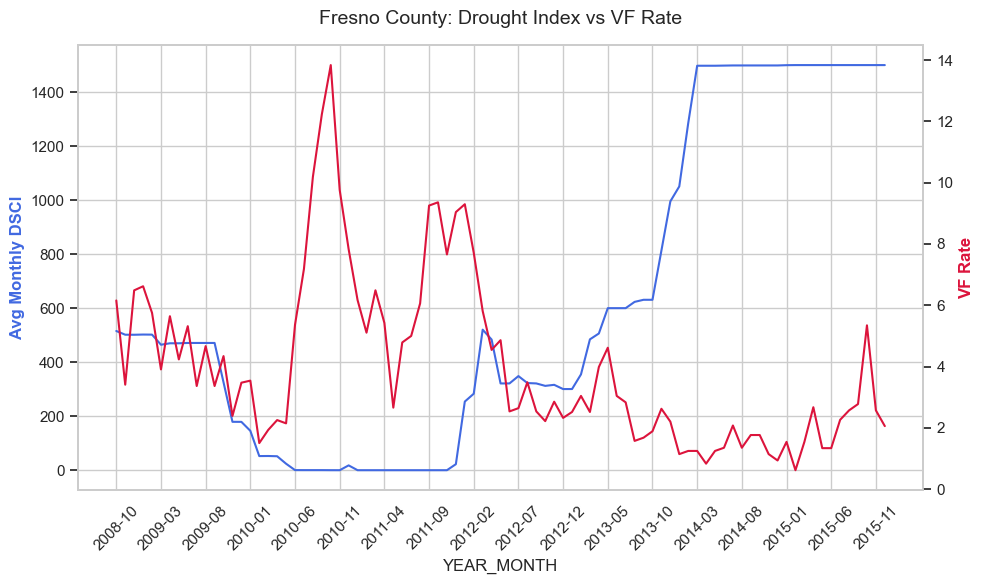

In [46]:
sns.set_theme(style="whitegrid") 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(data=df, x='YEAR_MONTH', y='Avg_Monthly_DSCI', ax=ax1, color='royalblue')
sns.lineplot(data=df, x='YEAR_MONTH', y='VFRate', ax=ax2, color='crimson')

ax1.tick_params(axis='x', rotation=45) 
current_ticks = ax1.get_xticks()
ax1.set_xticks(current_ticks[::5])

ax1.set_title(f"{county} County: Drought Index vs VF Rate", fontsize=14, pad=15)
ax1.set_ylabel("Avg Monthly DSCI", color='royalblue', fontweight='bold')
ax2.set_ylabel("VF Rate", color='crimson', fontweight='bold')
ax2.grid(False)
plt.tight_layout()
plt.show()


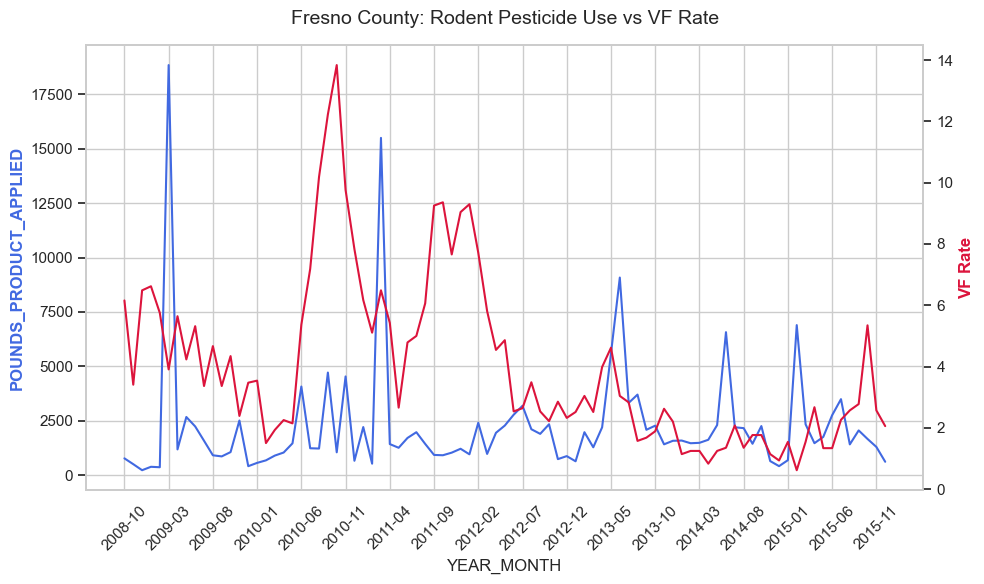

In [47]:
sns.set_theme(style="whitegrid") 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(data=df, x='YEAR_MONTH', y='POUNDS_PRODUCT_APPLIED', ax=ax1, color='royalblue')
sns.lineplot(data=df, x='YEAR_MONTH', y='VFRate', ax=ax2, color='crimson')

ax1.tick_params(axis='x', rotation=45) 
current_ticks = ax1.get_xticks()
ax1.set_xticks(current_ticks[::5])

ax1.set_title(f"{county} County: Rodent Pesticide Use vs VF Rate", fontsize=14, pad=15)
ax1.set_ylabel("POUNDS_PRODUCT_APPLIED", color='royalblue', fontweight='bold')
ax2.set_ylabel("VF Rate", color='crimson', fontweight='bold')
ax2.grid(False)
plt.tight_layout()
plt.show()


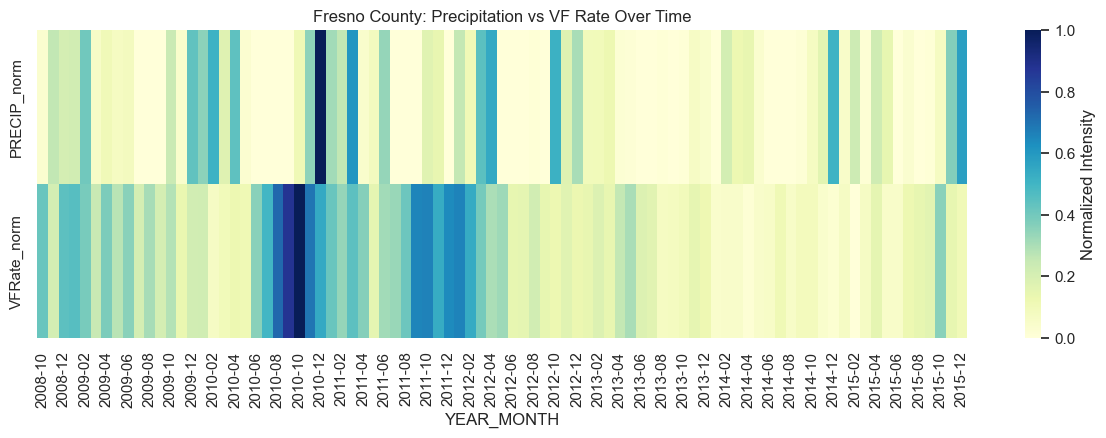

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data: normalize the scales so they share a 0-1 range for the colors
df_norm = df.copy()
df_norm['PRECIP_norm'] = (df['PRECIP'] - df['PRECIP'].min()) / (df['PRECIP'].max() - df['PRECIP'].min())
df_norm['VFRate_norm'] = (df['VFRate'] - df['VFRate'].min()) / (df['VFRate'].max() - df['VFRate'].min())

# Transpose for heatmap format
heat_df = df_norm.set_index('YEAR_MONTH')[['PRECIP_norm', 'VFRate_norm']].T

plt.figure(figsize=(15, 4))
sns.heatmap(heat_df, cmap="YlGnBu", cbar_kws={'label': 'Normalized Intensity'})
plt.title(f"{county} County: Precipitation vs VF Rate Over Time")
plt.show()

In [49]:
df.describe()

,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,POUNDS_PRODUCT_APPLIED,Avg_Monthly_DSCI
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,4.022209,99.292529,0.853103,0.264368,4.303793,103.301826,67.442529,32.264368,0.183908,1617.739402,2250.341285,614.101420
std,2.760574,156.268683,1.091071,0.599608,1.021575,24.507755,19.790975,12.298099,0.619991,2098.613819,2751.119050,575.763302
min,0.616709,0.000000,0.000000,0.000000,2.527778,60.838889,42.000000,11.000000,0.000000,0.000000,238.767500,0.000000
25%,2.065922,5.860000,0.020000,0.000000,3.404090,81.713571,55.000000,24.000000,0.000000,78.141883,953.767800,52.454000
50%,3.041012,27.100000,0.410000,0.000000,4.306452,103.312903,61.500000,29.000000,0.000000,737.626764,1495.257600,471.160000
75%,5.393994,127.310000,1.310000,0.000000,4.967419,119.019677,75.500000,41.000000,0.000000,2519.029075,2285.586650,1391.256250
max,13.838202,829.640000,5.740000,3.000000,6.720000,161.153333,140.000000,66.000000,5.000000,10167.267623,18831.611300,1500.000000


array([[<Axes: title={'center': 'VFRate'}>,
        <Axes: title={'center': 'FIRE_Acres_Burned'}>,
        <Axes: title={'center': 'PRECIP'}>],
       [<Axes: title={'center': 'WIND_EventCount'}>,
        <Axes: title={'center': 'WIND_AvgMPH'}>,
        <Axes: title={'center': 'WIND_RunMiles'}>],
       [<Axes: title={'center': 'AQI_PM25'}>,
        <Axes: title={'center': 'AQI_PM10'}>,
        <Axes: title={'center': 'EARTHQUAKE_Total'}>],
       [<Axes: title={'center': 'PESTICIDE_Total'}>,
        <Axes: title={'center': 'POUNDS_PRODUCT_APPLIED'}>,
        <Axes: title={'center': 'Avg_Monthly_DSCI'}>]], dtype=object)

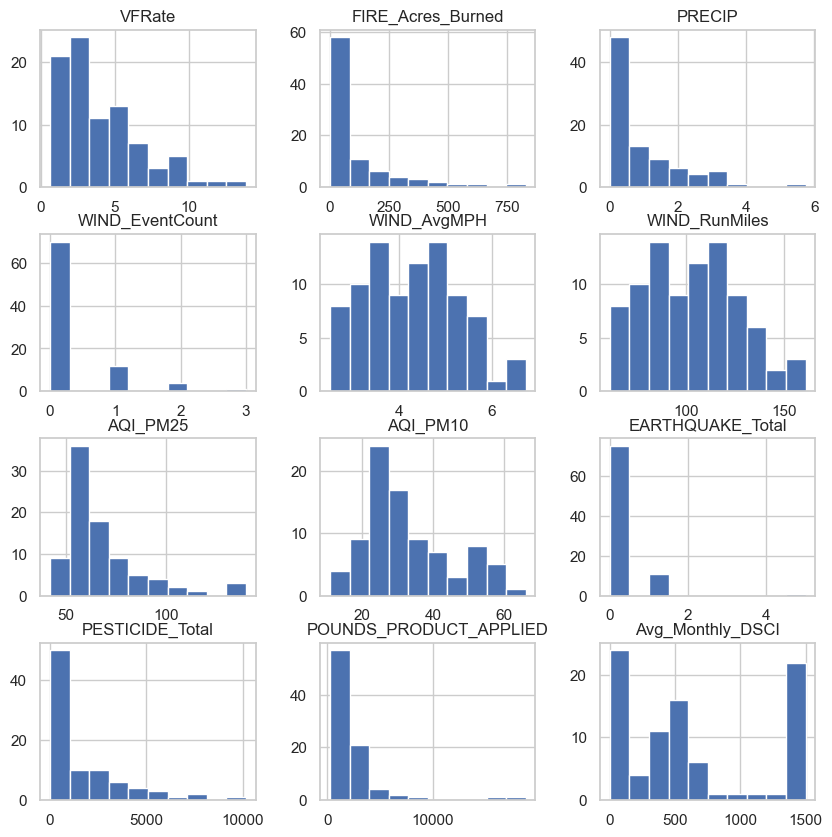

In [57]:
df.hist(figsize=(10,10))